# Four houses above 4000 square feet

Sort the file by living area and four houses stand apart. All four have overall quality 10.

| Id | Living area | Price | Neighborhood | Condition | Sale type |
|---:|---:|---:|---|---|---|
| 524 | 4676 | 184750 | Edwards | Partial | New |
| 1299 | 5642 | 160000 | Edwards | Partial | New |
| 692 | 4316 | 755000 | Northridge | Normal | WD |
| 1183 | 4476 | 745000 | Northridge | Abnorml | WD |

The dollar line from the living-area lesson, about $18569 + 107.13x$, prices the two Edwards houses near 519511 and 622999. They sold for 184750 and 160000. The two Northridge houses sold for 755000 and 745000, above that same line and in the direction a quality-10 house of this size suggests.

The Edwards pair is the unusual object: new, partial, quality 10, enormous, and sold far below the area line. They sit in a neighborhood whose median is 121750, so they do not even look strange if you only know the neighborhood median. They look strange when area and price are on the same page.

All four identifiers leave a nonzero remainder when divided by 5, so the later holdout, which keeps remainder 0, does not contain them. They can still tilt a line that is fit on the other rows.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "15-House Prices" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "data_description.txt").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["Id"], train[0]["SalePrice"])


1460 1459 1459
1 208500


In [3]:
# The four large houses, and where the area line would have priced the Edwards pair.
from fractions import Fraction
large = []
for row in train:
    if int(row["GrLivArea"]) >= 4000:
        large.append(row)
large.sort(key=lambda row: int(row["Id"]))
for row in large:
    print(
        row["Id"],
        row["GrLivArea"],
        row["SalePrice"],
        row["Neighborhood"],
        row["SaleCondition"],
        int(row["Id"]) % 5,
    )
assert [row["Id"] for row in large] == ["524", "692", "1183", "1299"]
assert all(row["OverallQual"] == "10" for row in large)
assert all(int(row["Id"]) % 5 != 0 for row in large)
areas = [int(row["GrLivArea"]) for row in train]
prices = [int(row["SalePrice"]) for row in train]
count = len(train)
sum_x, sum_y = sum(areas), sum(prices)
sum_xx = sum(area * area for area in areas)
sum_xy = sum(area * price for area, price in zip(areas, prices))
slope = Fraction(count * sum_xy - sum_x * sum_y, count * sum_xx - sum_x * sum_x)
intercept = Fraction(sum_y, count) - slope * Fraction(sum_x, count)
for area, actual in ((4676, 184750), (5642, 160000)):
    fitted = float(intercept + slope * area)
    print(area, round(fitted, 2), actual)
assert abs(float(intercept + slope * 4676) - 519510.5843806858) < 1e-4
assert abs(float(intercept + slope * 5642) - 622998.511141673) < 1e-4


524 4676 184750 Edwards Partial 4
692 4316 755000 NoRidge Normal 2
1183 4476 745000 NoRidge Abnorml 3
1299 5642 160000 Edwards Partial 4
4676 519510.58 184750
5642 622998.51 160000


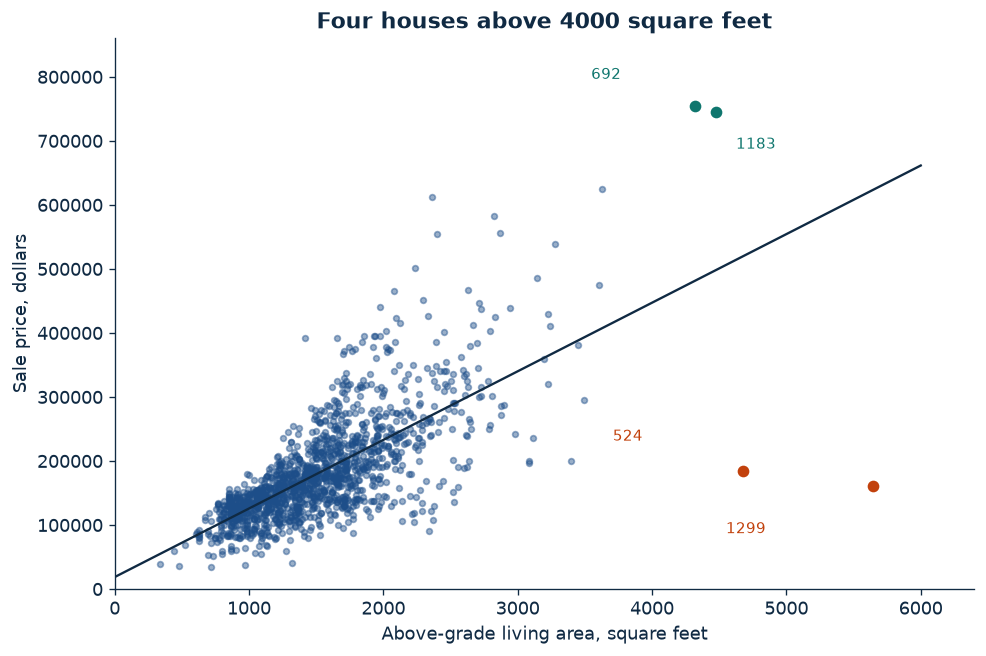

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# Living area against price, with the four large houses marked.
from fractions import Fraction
areas, prices, flags = [], [], []
for row in train:
    areas.append(int(row["GrLivArea"]))
    prices.append(int(row["SalePrice"]))
    flags.append(row["Id"])
count = len(areas)
sum_x, sum_y = sum(areas), sum(prices)
sum_xx = sum(area * area for area in areas)
sum_xy = sum(area * price for area, price in zip(areas, prices))
slope = Fraction(count * sum_xy - sum_x * sum_y, count * sum_xx - sum_x * sum_x)
intercept = Fraction(sum_y, count) - slope * Fraction(sum_x, count)
figure, axis = plt.subplots(figsize=(8.4, 5.6))
axis.scatter(areas, prices, s=12, color="#1d4e89", alpha=0.45)
line_x = [0, 6000]
line_y = [float(intercept + slope * x) for x in line_x]
axis.plot(line_x, line_y, color="#102a43", linewidth=1.4)
marks = {
    "524": ((-78, 18), "#c2410c"),
    "1299": ((-88, -28), "#c2410c"),
    "692": ((-62, 16), "#0f766e"),
    "1183": ((12, -22), "#0f766e"),
}
for row_id, (offset, color) in marks.items():
    index = flags.index(row_id)
    axis.scatter(
        [areas[index]],
        [prices[index]],
        s=36,
        color=color,
        zorder=3,
    )
    axis.annotate(
        row_id,
        (areas[index], prices[index]),
        textcoords="offset points",
        xytext=offset,
        color=color,
        fontsize=9,
    )
axis.set_xlim(0, 6400)
axis.set_ylim(0, 860000)
axis.set_xlabel("Above-grade living area, square feet")
axis.set_ylabel("Sale price, dollars")
axis.set_title("Four houses above 4000 square feet")
figure.tight_layout()


## Pitfall

The ink line was fit with these four houses included, and the two clay points still fall far below it. Deleting them is a judgment about partial new sales, not a step the formula takes by itself. This path keeps them in the file and reads them as partial sales.

## Summary

Ids 524 and 1299 are Edwards partial sales, 4676 and 5642 square feet, at 184750 and 160000. Ids 692 and 1183 are Northridge houses of similar size at 755000 and 745000. None of the four has `Id` divisible by 5.
